Image: 1152 x 2048

Loading SAM...
SAM ready.

Running SAM...
Raw masks: 38
Filtered masks: 32
Structural contours: 107
Candidate regions: 23
Useful geometric shapes: 26
After duplicate reduction: 19

Total ordered shapes: 19

Progressive drawing:
Step 1 shapes: 4
Step 2 shapes: 8
Step 3 shapes: 12
Step 4 shapes: 16
Final shapes: 19


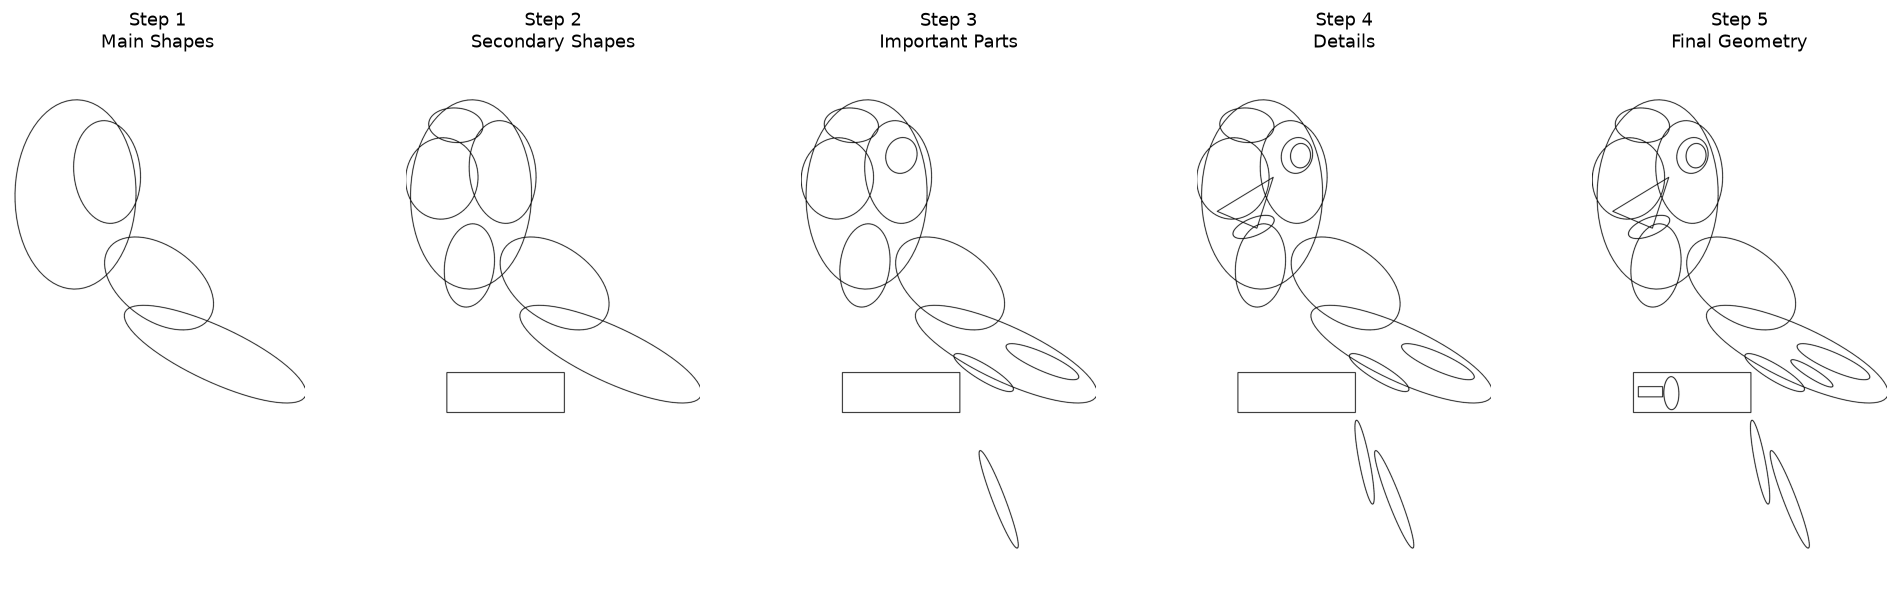


TATA VISION - PROGRESSIVE GEOMETRIC GUIDE
01 | oval       | area=0.0990 | compound-outer
02 | oval       | area=0.0450 | compound-outer
03 | oval       | area=0.0432 | simple
04 | oval       | area=0.0326 | compound-child
05 | oval       | area=0.0261 | compound-child
06 | oval       | area=0.0183 | compound-child
07 | rectangle  | area=0.0102 | compound-outer
08 | oval       | area=0.0084 | compound-child
09 | oval       | area=0.0065 | compound-child
10 | oval       | area=0.0065 | simple
11 | oval       | area=0.0057 | compound-outer
12 | oval       | area=0.0047 | simple
13 | triangle   | area=0.0046 | compound-child
14 | oval       | area=0.0046 | simple
15 | oval       | area=0.0036 | compound-child
16 | oval       | area=0.0024 | compound-child
17 | oval       | area=0.0022 | compound-child
18 | oval       | area=0.0019 | compound-child
19 | rectangle  | area=0.0014 | compound-child

OUTPUT FILES
Step 1 : C:\Users\Rifky\Downloads\tata_progressive_img5\img5_step1_main.png
Step 2

In [2]:
# ============================================================
# TATA VISION
# V5 GEOMETRIC + PROGRESSIVE DRAWING STEPS
#
# Original Image
#       ↓
# SAM
#       ↓
# V5 Primitive Detection
#       ↓
# SIMPLE + COMPOUND
#       ↓
# Sort shapes by importance
#       ↓
# Step 1 -> Main construction
# Step 2 -> Secondary construction
# Step 3 -> Details
# Final  -> Complete geometric guide
#
# COMPLEX REGIONS ARE SKIPPED
# ============================================================

import os

# SAM ViT-H -> CPU
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import cv2
import numpy as np
import matplotlib.pyplot as plt

from segment_anything import (
    sam_model_registry,
    SamAutomaticMaskGenerator
)


# ============================================================
# 0. PATHS
# ============================================================

INPUT_IMAGE = (
    r"C:\Users\Rifky\Documents\TATA_vision"
    r"\Dataset\Dataset\img5.png"
)

SAM_CHECKPOINT = (
    r"C:\Users\Rifky\Downloads\tata-vision-leader"
    r"\ai-services\models\sam_vit_h_4b8939.pth"
)

OUTPUT_DIR = (
    r"C:\Users\Rifky\Downloads"
    r"\tata_progressive_img5"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# ============================================================
# 1. LOAD IMAGE
# ============================================================

if not os.path.exists(INPUT_IMAGE):
    raise FileNotFoundError(INPUT_IMAGE)

if not os.path.exists(SAM_CHECKPOINT):
    raise FileNotFoundError(SAM_CHECKPOINT)


original_bgr = cv2.imread(INPUT_IMAGE)

if original_bgr is None:
    raise RuntimeError(
        "Could not read input image."
    )


original_rgb = cv2.cvtColor(
    original_bgr,
    cv2.COLOR_BGR2RGB
)

H, W = original_bgr.shape[:2]

IMAGE_AREA = float(
    H * W
)

print(
    "Image:",
    W,
    "x",
    H
)


# ============================================================
# 2. LOAD SAM
# ============================================================

print("\nLoading SAM...")

sam = sam_model_registry["vit_h"](
    checkpoint=SAM_CHECKPOINT
)

sam.to(
    device="cpu"
)

mask_generator = SamAutomaticMaskGenerator(

    model=sam,

    points_per_side=32,

    pred_iou_thresh=0.88,

    stability_score_thresh=0.92,

    crop_n_layers=0,

    min_mask_region_area=100
)

print("SAM ready.")


# ============================================================
# 3. RUN SAM
# ============================================================

print("\nRunning SAM...")

sam_masks = mask_generator.generate(
    original_rgb
)

print(
    "Raw masks:",
    len(sam_masks)
)


# ============================================================
# 4. FILTER SAM MASKS
# ============================================================

filtered_masks = []

for info in sam_masks:

    seg = info["segmentation"]

    area = np.count_nonzero(
        seg
    )

    ratio = (
        area / IMAGE_AREA
    )

    pred_iou = float(
        info.get(
            "predicted_iou",
            0
        )
    )

    stability = float(
        info.get(
            "stability_score",
            0
        )
    )

    if not (
        0.001 <= ratio <= 0.40
    ):
        continue

    if pred_iou < 0.88:
        continue

    if stability < 0.92:
        continue

    filtered_masks.append(
        info
    )


print(
    "Filtered masks:",
    len(filtered_masks)
)

if not filtered_masks:

    raise RuntimeError(
        "No SAM masks passed filtering."
    )


# ============================================================
# 5. INTERNAL SAM STRUCTURAL MAP
#
# Not saved.
# Used internally by geometric stage.
# ============================================================

structure = np.ones(
    (H, W, 3),
    dtype=np.uint8
) * 255


for info in filtered_masks:

    seg = (
        info["segmentation"]
        .astype(np.uint8)
        * 255
    )

    cs, _ = cv2.findContours(
        seg,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    cv2.drawContours(
        structure,
        cs,
        -1,
        (0, 0, 0),
        1,
        cv2.LINE_AA
    )


# ============================================================
# 6. STRUCTURE -> BINARY
# ============================================================

gray = cv2.cvtColor(
    structure,
    cv2.COLOR_BGR2GRAY
)

_, bw = cv2.threshold(
    gray,
    200,
    255,
    cv2.THRESH_BINARY_INV
)


kernel = cv2.getStructuringElement(
    cv2.MORPH_ELLIPSE,
    (3, 3)
)


bw = cv2.morphologyEx(
    bw,
    cv2.MORPH_CLOSE,
    kernel,
    iterations=1
)


# ============================================================
# 7. STRUCTURAL CONTOURS
# ============================================================

contours, hierarchy = cv2.findContours(
    bw,
    cv2.RETR_TREE,
    cv2.CHAIN_APPROX_NONE
)


if hierarchy is None:

    raise RuntimeError(
        "No contours found."
    )


hierarchy = hierarchy[0]


print(
    "Structural contours:",
    len(contours)
)


# ============================================================
# 8. MASK HELPER
# ============================================================

def contour_mask(cnt):

    mask = np.zeros(
        (H, W),
        dtype=np.uint8
    )

    cv2.drawContours(
        mask,
        [cnt],
        -1,
        255,
        -1
    )

    return mask


# ============================================================
# 9. FIT EVALUATION
# ============================================================

def evaluate_candidate(
    region_mask,
    candidate_mask
):

    region = (
        region_mask > 0
    )

    candidate = (
        candidate_mask > 0
    )


    intersection = np.logical_and(
        region,
        candidate
    ).sum()


    union = np.logical_or(
        region,
        candidate
    ).sum()


    region_area = region.sum()

    candidate_area = candidate.sum()


    iou = (
        intersection / union
        if union > 0
        else 0
    )


    coverage = (
        intersection / region_area
        if region_area > 0
        else 0
    )


    outside = (
        (candidate_area - intersection)
        / candidate_area
        if candidate_area > 0
        else 1
    )


    score = (
        0.50 * iou
        + 0.35 * coverage
        - 0.35 * outside
    )


    return (
        iou,
        coverage,
        outside,
        score
    )


# ============================================================
# 10. PRIMITIVE CANDIDATES
# ============================================================

def primitive_candidates(cnt):

    region_mask = contour_mask(
        cnt
    )

    candidates = []


    # --------------------------------------------------------
    # CIRCLE
    # --------------------------------------------------------

    (cx, cy), radius = (
        cv2.minEnclosingCircle(
            cnt
        )
    )


    mask = np.zeros(
        (H, W),
        dtype=np.uint8
    )


    cv2.circle(
        mask,
        (
            int(round(cx)),
            int(round(cy))
        ),
        max(
            1,
            int(round(radius))
        ),
        255,
        -1
    )


    values = evaluate_candidate(
        region_mask,
        mask
    )


    candidates.append(
        (
            "circle",
            *values
        )
    )


    # --------------------------------------------------------
    # OVAL
    # --------------------------------------------------------

    if len(cnt) >= 5:

        try:

            ellipse = cv2.fitEllipse(
                cnt
            )


            mask = np.zeros(
                (H, W),
                dtype=np.uint8
            )


            cv2.ellipse(
                mask,
                ellipse,
                255,
                -1
            )


            values = evaluate_candidate(
                region_mask,
                mask
            )


            candidates.append(
                (
                    "oval",
                    *values
                )
            )

        except cv2.error:

            pass


    # --------------------------------------------------------
    # RECTANGLE / SQUARE
    # --------------------------------------------------------

    rect = cv2.minAreaRect(
        cnt
    )


    box = cv2.boxPoints(
        rect
    )


    box = np.int32(
        np.round(box)
    )


    mask = np.zeros(
        (H, W),
        dtype=np.uint8
    )


    cv2.fillPoly(
        mask,
        [box],
        255
    )


    values = evaluate_candidate(
        region_mask,
        mask
    )


    rw, rh = rect[1]


    if rw > 0 and rh > 0:

        aspect = (
            max(rw, rh)
            / min(rw, rh)
        )


        if aspect <= 1.20:

            shape_type = "square"

        else:

            shape_type = "rectangle"

    else:

        shape_type = "rectangle"


    candidates.append(
        (
            shape_type,
            *values
        )
    )


    # --------------------------------------------------------
    # TRIANGLE
    # --------------------------------------------------------

    try:

        _, tri = cv2.minEnclosingTriangle(
            cnt.astype(
                np.float32
            )
        )


        if tri is not None:

            tri = np.int32(
                np.round(
                    tri.reshape(
                        3,
                        2
                    )
                )
            )


            mask = np.zeros(
                (H, W),
                dtype=np.uint8
            )


            cv2.fillPoly(
                mask,
                [tri],
                255
            )


            values = evaluate_candidate(
                region_mask,
                mask
            )


            candidates.append(
                (
                    "triangle",
                    *values
                )
            )


    except cv2.error:

        pass


    candidates.sort(
        key=lambda x: x[4],
        reverse=True
    )


    return candidates


# ============================================================
# 11. SMART BEST
# ============================================================

def smart_best(
    region,
    candidates
):

    if not candidates:

        return None


    best = candidates[0]


    by_type = {

        item[0]: item

        for item in candidates
    }


    # --------------------------------------------------------
    # Triangle / oval protection
    # --------------------------------------------------------

    if best[0] == "triangle":

        oval = by_type.get(
            "oval"
        )


        if oval is not None:

            score_gap = (
                best[4]
                - oval[4]
            )


            if (
                region["vertices"] > 3
                and score_gap <= 0.03
                and oval[1] >= 0.70
                and oval[2] >= 0.85
                and oval[3] <= 0.25
            ):

                best = oval


    return best


# ============================================================
# 12. USEFUL CHILDREN
# ============================================================

def useful_children(
    parent_index
):

    result = []


    child = hierarchy[
        parent_index
    ][2]


    while child != -1:

        cnt = contours[
            child
        ]


        area = cv2.contourArea(
            cnt
        )


        ratio = (
            area / IMAGE_AREA
        )


        if ratio >= 0.00035:

            x, y, w, h = (
                cv2.boundingRect(
                    cnt
                )
            )


            if (
                w >= 5
                and h >= 5
            ):

                result.append(
                    (
                        child,
                        cnt
                    )
                )


        child = hierarchy[
            child
        ][0]


    return result


# ============================================================
# 13. BUILD REGIONS
# ============================================================

regions = []


for contour_index, cnt in enumerate(
    contours
):

    area = cv2.contourArea(
        cnt
    )


    if area <= 0:
        continue


    area_ratio = (
        area / IMAGE_AREA
    )


    if not (
        0.004
        <= area_ratio
        <= 0.20
    ):

        continue


    x, y, w, h = (
        cv2.boundingRect(
            cnt
        )
    )


    if (
        w < 8
        or h < 8
    ):

        continue


    perimeter = cv2.arcLength(
        cnt,
        True
    )


    if perimeter <= 0:

        continue


    approx = cv2.approxPolyDP(
        cnt,
        0.04 * perimeter,
        True
    )


    children = useful_children(
        contour_index
    )


    regions.append({

        "contour_index":
            contour_index,

        "contour":
            cnt,

        "area":
            area,

        "area_ratio":
            area_ratio,

        "vertices":
            len(approx),

        "bbox":
            (x, y, w, h),

        "children":
            children,

        "child_count":
            len(children)
    })


print(
    "Candidate regions:",
    len(regions)
)


# ============================================================
# 14. CLASSIFY
# ============================================================

def classify_region(
    region
):

    candidates = primitive_candidates(
        region["contour"]
    )


    best = smart_best(
        region,
        candidates
    )


    # --------------------------------------------------------
    # COMPOUND
    # --------------------------------------------------------

    if region["child_count"] >= 2:

        return (
            "COMPOUND",
            best
        )


    # --------------------------------------------------------
    # COMPLEX
    # --------------------------------------------------------

    if best is None:

        return (
            "COMPLEX",
            None
        )


    shape, iou, cov, out, score = best


    # --------------------------------------------------------
    # SIMPLE
    # --------------------------------------------------------

    if (
        iou >= 0.72
        and cov >= 0.85
        and out <= 0.25
    ):

        return (
            "SIMPLE",
            best
        )


    # --------------------------------------------------------
    # COMPLEX
    # --------------------------------------------------------

    return (
        "COMPLEX",
        best
    )


# ============================================================
# 15. LOCAL CHILD FIT
# ============================================================

def local_fit(
    cnt
):

    if cnt is None:

        return None


    if len(cnt) < 3:

        return None


    area = cv2.contourArea(
        cnt
    )


    if area <= 0:

        return None


    perimeter = cv2.arcLength(
        cnt,
        True
    )


    if perimeter <= 0:

        return None


    approx = cv2.approxPolyDP(
        cnt,
        0.04 * perimeter,
        True
    )


    candidates = primitive_candidates(
        cnt
    )


    if not candidates:

        return None


    temp_region = {

        "vertices":
            len(approx)
    }


    best = smart_best(
        temp_region,
        candidates
    )


    if best is None:

        return None


    shape, iou, cov, out, score = best


    if (
        iou >= 0.58
        and cov >= 0.72
        and out <= 0.38
    ):

        return best


    return None


# ============================================================
# 16. COLLECT FINAL GEOMETRIC SHAPES
#
# Instead of drawing immediately,
# store each useful shape.
# ============================================================

detected_shapes = []


for region_id, region in enumerate(
    regions
):

    label, best = classify_region(
        region
    )


    # ========================================================
    # SIMPLE
    # ========================================================

    if label == "SIMPLE":

        if best is None:
            continue


        detected_shapes.append({

            "contour":
                region["contour"],

            "type":
                best[0],

            "area":
                region["area"],

            "area_ratio":
                region["area_ratio"],

            "source":
                "simple",

            "region":
                region_id
        })


    # ========================================================
    # COMPOUND
    # ========================================================

    elif label == "COMPOUND":

        # ----------------------------------------------------
        # Outer shape
        # ----------------------------------------------------

        if best is not None:

            detected_shapes.append({

                "contour":
                    region["contour"],

                "type":
                    best[0],

                "area":
                    region["area"],

                "area_ratio":
                    region["area_ratio"],

                "source":
                    "compound-outer",

                "region":
                    region_id
            })


        # ----------------------------------------------------
        # Child shapes
        # ----------------------------------------------------

        for (
            child_index,
            child_cnt
        ) in region["children"]:


            child_best = local_fit(
                child_cnt
            )


            if child_best is None:

                continue


            child_area = cv2.contourArea(
                child_cnt
            )


            detected_shapes.append({

                "contour":
                    child_cnt,

                "type":
                    child_best[0],

                "area":
                    child_area,

                "area_ratio":
                    child_area
                    / IMAGE_AREA,

                "source":
                    "compound-child",

                "region":
                    region_id
            })


    # ========================================================
    # COMPLEX
    #
    # Skip completely.
    # ========================================================

    elif label == "COMPLEX":

        continue


print(
    "Useful geometric shapes:",
    len(detected_shapes)
)


if not detected_shapes:

    raise RuntimeError(
        "No useful geometric shapes detected."
    )


# ============================================================
# 17. DUPLICATE REDUCTION
#
# Avoid the exact same primitive being drawn repeatedly.
# ============================================================

def shape_center(
    item
):

    cnt = item["contour"]

    M = cv2.moments(
        cnt
    )


    if M["m00"] != 0:

        cx = (
            M["m10"]
            / M["m00"]
        )

        cy = (
            M["m01"]
            / M["m00"]
        )

    else:

        x, y, w, h = (
            cv2.boundingRect(
                cnt
            )
        )

        cx = x + w / 2
        cy = y + h / 2


    return (
        float(cx),
        float(cy)
    )


# Sort biggest first
detected_shapes.sort(
    key=lambda item: item["area"],
    reverse=True
)


unique_shapes = []


for candidate in detected_shapes:

    cx, cy = shape_center(
        candidate
    )


    duplicate = False


    for existing in unique_shapes:

        if (
            candidate["type"]
            != existing["type"]
        ):

            continue


        ex, ey = shape_center(
            existing
        )


        distance = np.hypot(
            cx - ex,
            cy - ey
        )


        candidate_scale = np.sqrt(
            max(
                candidate["area"],
                1
            )
        )


        existing_scale = np.sqrt(
            max(
                existing["area"],
                1
            )
        )


        scale = max(
            candidate_scale,
            existing_scale
        )


        area_ratio = (
            min(
                candidate["area"],
                existing["area"]
            )
            /
            max(
                candidate["area"],
                existing["area"]
            )
        )


        if (
            distance
            <= 0.08 * scale
            and area_ratio >= 0.85
        ):

            duplicate = True
            break


    if not duplicate:

        unique_shapes.append(
            candidate
        )


detected_shapes = unique_shapes


print(
    "After duplicate reduction:",
    len(detected_shapes)
)


# ============================================================
# 18. DRAW ONE GEOMETRIC PRIMITIVE
# ============================================================

def draw_shape(
    canvas,
    item,
    thickness=2
):

    cnt = item["contour"]

    shape_type = item["type"]


    # --------------------------------------------------------
    # CIRCLE
    # --------------------------------------------------------

    if shape_type == "circle":

        (cx, cy), radius = (
            cv2.minEnclosingCircle(
                cnt
            )
        )


        cv2.circle(
            canvas,
            (
                int(round(cx)),
                int(round(cy))
            ),
            max(
                1,
                int(round(radius))
            ),
            (0, 0, 0),
            thickness,
            cv2.LINE_AA
        )


    # --------------------------------------------------------
    # OVAL
    # --------------------------------------------------------

    elif shape_type == "oval":

        if len(cnt) >= 5:

            try:

                ellipse = cv2.fitEllipse(
                    cnt
                )


                cv2.ellipse(
                    canvas,
                    ellipse,
                    (0, 0, 0),
                    thickness,
                    cv2.LINE_AA
                )


            except cv2.error:

                pass


    # --------------------------------------------------------
    # RECTANGLE / SQUARE
    # --------------------------------------------------------

    elif shape_type in (
        "rectangle",
        "square"
    ):

        rect = cv2.minAreaRect(
            cnt
        )


        box = cv2.boxPoints(
            rect
        )


        box = np.int32(
            np.round(box)
        )


        cv2.polylines(
            canvas,
            [box],
            True,
            (0, 0, 0),
            thickness,
            cv2.LINE_AA
        )


    # --------------------------------------------------------
    # TRIANGLE
    # --------------------------------------------------------

    elif shape_type == "triangle":

        try:

            _, tri = (
                cv2.minEnclosingTriangle(
                    cnt.astype(
                        np.float32
                    )
                )
            )


            if tri is not None:

                tri = np.int32(
                    np.round(
                        tri.reshape(
                            3,
                            2
                        )
                    )
                )


                cv2.polylines(
                    canvas,
                    [tri],
                    True,
                    (0, 0, 0),
                    thickness,
                    cv2.LINE_AA
                )


        except cv2.error:

            pass


# ============================================================
# 19. DRAWING ORDER
#
# Largest / most important shapes first.
#
# This is the progressive drawing logic.
# ============================================================

ordered_shapes = sorted(

    detected_shapes,

    key=lambda item:
        item["area"],

    reverse=True
)


N = len(
    ordered_shapes
)


print(
    "\nTotal ordered shapes:",
    N
)

# ============================================================
# 20. PROGRESSIVE STEP COUNTS
#
# Step 1 -> Main construction
# Step 2 -> Secondary construction
# Step 3 -> More parts
# Step 4 -> Fine details
# Final  -> Complete geometry
#
# Reference image is NOT included in preview.
# All steps are cumulative.
# ============================================================

if N == 1:

    step1_n = 1
    step2_n = 1
    step3_n = 1
    step4_n = 1

elif N == 2:

    step1_n = 1
    step2_n = 1
    step3_n = 1
    step4_n = 2

elif N == 3:

    step1_n = 1
    step2_n = 1
    step3_n = 2
    step4_n = 3

elif N == 4:

    step1_n = 1
    step2_n = 2
    step3_n = 3
    step4_n = 4

else:

    # 20%, 40%, 60%, 80%, 100%
    step1_n = max(
        1,
        int(np.ceil(N * 0.20))
    )

    step2_n = max(
        step1_n,
        int(np.ceil(N * 0.40))
    )

    step3_n = max(
        step2_n,
        int(np.ceil(N * 0.60))
    )

    step4_n = max(
        step3_n,
        int(np.ceil(N * 0.80))
    )


print("\nProgressive drawing:")

print(
    "Step 1 shapes:",
    step1_n
)

print(
    "Step 2 shapes:",
    step2_n
)

print(
    "Step 3 shapes:",
    step3_n
)

print(
    "Step 4 shapes:",
    step4_n
)

print(
    "Final shapes:",
    N
)


# ============================================================
# 21. CREATE A STEP IMAGE
# ============================================================

def create_step_image(shapes):

    canvas = np.ones(
        (H, W, 3),
        dtype=np.uint8
    ) * 255

    for item in shapes:

        draw_shape(
            canvas,
            item,
            thickness=2
        )

    return canvas


# ============================================================
# 22. CREATE 5 CUMULATIVE DRAWING STAGES
# ============================================================

step1 = create_step_image(
    ordered_shapes[:step1_n]
)

step2 = create_step_image(
    ordered_shapes[:step2_n]
)

step3 = create_step_image(
    ordered_shapes[:step3_n]
)

step4 = create_step_image(
    ordered_shapes[:step4_n]
)

final_geo = create_step_image(
    ordered_shapes
)


# ============================================================
# 23. SAVE ALL DRAWING STEPS
# ============================================================

STEP1_PATH = os.path.join(
    OUTPUT_DIR,
    "img5_step1_main.png"
)

STEP2_PATH = os.path.join(
    OUTPUT_DIR,
    "img5_step2_secondary.png"
)

STEP3_PATH = os.path.join(
    OUTPUT_DIR,
    "img5_step3_parts.png"
)

STEP4_PATH = os.path.join(
    OUTPUT_DIR,
    "img5_step4_details.png"
)

FINAL_PATH = os.path.join(
    OUTPUT_DIR,
    "img5_step5_final.png"
)


cv2.imwrite(
    STEP1_PATH,
    step1
)

cv2.imwrite(
    STEP2_PATH,
    step2
)

cv2.imwrite(
    STEP3_PATH,
    step3
)

cv2.imwrite(
    STEP4_PATH,
    step4
)

cv2.imwrite(
    FINAL_PATH,
    final_geo
)


# ============================================================
# 24. PREVIEW
#
# IMPORTANT:
# Reference/original image is NOT shown.
#
# Step 1 -> Step 2 -> Step 3 -> Step 4 -> Final
# ============================================================

preview_images = [

    step1,
    step2,
    step3,
    step4,
    final_geo
]


titles = [

    "Step 1\nMain Shapes",

    "Step 2\nSecondary Shapes",

    "Step 3\nImportant Parts",

    "Step 4\nDetails",

    "Step 5\nFinal Geometry"
]


# ============================================================
# 25. DISPLAY PROGRESSIVE DRAWING GUIDE
# ============================================================

fig, axes = plt.subplots(
    1,
    5,
    figsize=(20, 6)
)


for ax, image, title in zip(
    axes,
    preview_images,
    titles
):

    ax.imshow(
        cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )
    )

    ax.set_title(
        title,
        fontsize=13
    )

    ax.axis(
        "off"
    )


plt.tight_layout()


PREVIEW_PATH = os.path.join(
    OUTPUT_DIR,
    "img5_progressive_5_steps.png"
)


plt.savefig(
    PREVIEW_PATH,
    dpi=180,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 26. REPORT DRAWING ORDER
# ============================================================

print(
    "\n"
    + "=" * 75
)

print(
    "TATA VISION - PROGRESSIVE GEOMETRIC GUIDE"
)

print(
    "=" * 75
)


for i, item in enumerate(
    ordered_shapes,
    start=1
):

    print(
        f"{i:02d}"
        f" | {item['type']:10s}"
        f" | area={item['area_ratio']:.4f}"
        f" | {item['source']}"
    )


print(
    "\n"
    + "=" * 75
)

print(
    "OUTPUT FILES"
)

print(
    "=" * 75
)


print(
    "Step 1 :",
    STEP1_PATH
)

print(
    "Step 2 :",
    STEP2_PATH
)

print(
    "Step 3 :",
    STEP3_PATH
)

print(
    "Step 4 :",
    STEP4_PATH
)

print(
    "Final  :",
    FINAL_PATH
)

print(
    "Preview:",
    PREVIEW_PATH
)

print(
    "\nDONE."
)

In [ ]:
# ============================================================
# 27. CLICKABLE GRID -> RELATED GEOMETRIC VIEWS
# Run this cell after the SAM/geometric pipeline above.
# Click the first image to inspect the same grid area in related stages.
# ============================================================

try:
    get_ipython().run_line_magic("matplotlib", "widget")
except Exception as exc:
    print("Install ipympl, restart Jupyter, and rerun this cell.")
    raise exc

GRID_ROWS = 4
GRID_COLS = 4

related_images = [
    ("SAM structure", cv2.cvtColor(structure, cv2.COLOR_BGR2RGB)),
    ("Step 1", cv2.cvtColor(step1, cv2.COLOR_BGR2RGB)),
    ("Step 2", cv2.cvtColor(step2, cv2.COLOR_BGR2RGB)),
    ("Step 3", cv2.cvtColor(step3, cv2.COLOR_BGR2RGB)),
    ("Step 4", cv2.cvtColor(step4, cv2.COLOR_BGR2RGB)),
    ("Final geometry", cv2.cvtColor(final_geo, cv2.COLOR_BGR2RGB)),
]

grid_figure = plt.figure(figsize=(17, 9))
layout = grid_figure.add_gridspec(2, 4, width_ratios=[1.2, 1, 1, 1])
grid_axis = grid_figure.add_subplot(layout[:, 0])
detail_axes = [
    grid_figure.add_subplot(layout[i // 3, 1 + i % 3])
    for i in range(6)
]

grid_axis.imshow(original_rgb)
grid_axis.set_title("Click a grid cell", fontsize=14)
grid_axis.set_xlim(0, W)
grid_axis.set_ylim(H, 0)
grid_axis.set_xticks(np.linspace(0, W, GRID_COLS + 1))
grid_axis.set_yticks(np.linspace(0, H, GRID_ROWS + 1))
grid_axis.grid(color="#00e5ff", linewidth=1.8)
grid_axis.tick_params(labelbottom=False, labelleft=False, length=0)
selection_box = None

def show_related_grid_cell(row, col):
    global selection_box
    x0 = int(round(col * W / GRID_COLS))
    x1 = int(round((col + 1) * W / GRID_COLS))
    y0 = int(round(row * H / GRID_ROWS))
    y1 = int(round((row + 1) * H / GRID_ROWS))

    if selection_box is not None:
        selection_box.remove()
    selection_box = plt.Rectangle(
        (x0, y0), x1 - x0, y1 - y0, fill=False,
        edgecolor="#ff2d55", linewidth=4
    )
    grid_axis.add_patch(selection_box)
    grid_axis.set_title(f"Selected: row {row + 1}, column {col + 1}")

    for axis, (title, image) in zip(detail_axes, related_images):
        axis.clear()
        axis.imshow(image[y0:y1, x0:x1])
        axis.set_title(title)
        axis.axis("off")

    grid_figure.canvas.draw_idle()

def on_grid_click(event):
    if event.inaxes is not grid_axis or event.xdata is None or event.ydata is None:
        return
    col = min(GRID_COLS - 1, max(0, int(event.xdata * GRID_COLS / W)))
    row = min(GRID_ROWS - 1, max(0, int(event.ydata * GRID_ROWS / H)))
    show_related_grid_cell(row, col)

grid_figure.canvas.mpl_connect("button_press_event", on_grid_click)
show_related_grid_cell(GRID_ROWS // 2, GRID_COLS // 2)
grid_figure.suptitle("SAM geometric extraction - related views", fontsize=16)
grid_figure.tight_layout()
plt.show()
